<a href="https://colab.research.google.com/github/larscaspersen/phenoflex_meets_bayes/blob/main/hybridmodel_phenoflex.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#!pip install -q numpyro==0.14.0 jax==0.4.26 jaxlib==0.4.26 arviz causalgraphicalmodels daft
!pip install -q numpyro jax jaxlib arviz causalgraphicalmodels daft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 388.0/388.0 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.7/56.7 MB 11.9 MB/s eta 0:00:00


In [2]:
# %%
import argparse
import os
import time
import matplotlib.pyplot as plt
import numpy as np
import jax
from jax import random
import jax.numpy as jnp
import arviz as az
import numpyro
from numpyro.contrib.control_flow import scan
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive
# Building on numpyro AR2 example: https://num.pyro.ai/en/latest/examples/ar2.html

In [6]:
import pandas as pd

In [3]:
def run_inference(model, args, rng_key, dat):
    start = time.time()
    sampler = numpyro.infer.NUTS(model)
    mcmc = numpyro.infer.MCMC(
        sampler,
        num_warmup=args['num_warmup'],
        num_samples=args['num_samples'],
        num_chains=args['num_chains'],
        progress_bar=False if "NUMPYRO_SPHINXBUILD" in os.environ else True,
    )
    mcmc.run(rng_key, **dat)
    mcmc.print_summary()
    az_mcmc = az.from_numpyro(mcmc)
    print("\nMCMC elapsed time:", time.time() - start)
    return mcmc, mcmc.get_samples(), az_mcmc


The standard phenoflex model. Converted from c++ code with claude

I changed the values of E0, E1, A0 and A1 to standard dynamic model. in phenoflex they use the wrong default parameters

In [4]:
# ── Helper functions

#gdh model
def P1z(T: float, Tu: float, Tb: float, Tc: float) -> float:
    """GDH heat-accumulation rate (triangular bell, model 0)."""
    if Tb <= T <= Tu:
        return 0.5 * (1 + np.cos(np.pi + np.pi * (T - Tb) / (Tu - Tb)))
    elif Tu < T <= Tc:
        return 1 + np.cos(np.pi / 2 + np.pi / 2 * (T - Tu) / (Tc - Tu))
    return 0.0

 #alternative heat accumulation model
def P2z(T: float, Tu: float, Delta: float) -> float:
    """Gaussian heat-accumulation rate (model 1)."""
    return np.exp(-((T - Tu) / (2 * Delta)) ** 2)

#transition function (either PDBF to DBF or Py for effective heat accumulation)
def PFcn(T: float, Tf: float, slope: float) -> float:
    """Sigmoid that controls labile→stable chill conversion and heat sensitivity."""
    x = slope * Tf * (T - Tf) / T
    if x >= 17:
        return 1.0
    if x <= -20:
        return 0.0
    sr = np.exp(x)
    return sr / (1 + sr)


def phenoflex(
    temp,
    times,
    yc: float = 40.0,
    zc: float = 190.0,
    s1: float = 0.5,
    E0: float = 4153.5,
    E1: float = 12888.8,
    A0: float = 139500,
    A1: float = 2567000000000000000,
    Tf: float = 4.0,
    slope: float = 1.6,
    Tb: float = 4.0,
    Tu: float = 26.0,
    Tc: float = 36.0,
    Delta: float = 4.0,
    Imodel: int = 0,
    stopatzc: bool = True,
    deg_celsius: bool = True,
    basic_output: bool = True,
) -> dict:
    """
    Python translation of the PhenoFlex C++ / Rcpp model.

    Parameters
    ----------
    temp       : array-like of hourly temperatures
    times      : array-like of corresponding time stamps (hours)
    yc         : chill requirement (stable chill units)
    zc         : heat requirement (GDH or GDD units)
    s1         : slope of PFcn sigmoid for heat sensitivity
    E0, E1     : activation energies for chill pool dynamics
    A0, A1     : pre-exponential factors for chill pool dynamics
    Tf         : base temperature for labile-to-stable chill conversion (°C)
    slope      : steepness of the labile-to-stable sigmoid
    Tb, Tu, Tc : base, optimum, ceiling temperatures for heat model 0 (°C)
    Delta      : half-width for Gaussian heat model 1 (°C)
    Imodel     : 0 = GDH triangular bell, 1 = Gaussian
    stopatzc   : stop simulation once zc is reached
    deg_celsius: True if temperatures are in °C (will be converted to K internally)
    basic_output: True → return only bloomindex; False → return full state arrays

    Returns
    -------
    dict with 'bloomindex' (and optionally 'x', 'y', 'z', 'xs')
    """
    temp = np.asarray(temp, dtype=float)
    times = np.asarray(times, dtype=float)
    N = len(temp)

    x = np.zeros(N)   # labile chill pool
    y = np.zeros(N)   # stable chill pool
    z = np.zeros(N)   # accumulated heat
    xs = np.zeros(N)  # equilibrium labile chill

    # Convert threshold temperatures to Kelvin if needed
    _Tf = Tf + 273.0 if deg_celsius else Tf
    _Tu = Tu + 273.0 if deg_celsius else Tu
    _Tc = Tc + 273.0 if deg_celsius else Tc
    _Tb = Tb + 273.0 if deg_celsius else Tb

    bloomindex = 0

    for i in range(N - 1):
        ti = temp[i] + 273.0 if deg_celsius else temp[i]
        dt = times[i + 1] - times[i]

        # Equilibrium labile chill and rate constant
        xs[i] = A0 / A1 * np.exp(-(E0 - E1) / ti)
        k1 = A1 * np.exp(-E1 / ti)

        # Update labile chill pool (exponential relaxation toward equilibrium)
        x[i + 1] = xs[i] - (xs[i] - x[i]) * np.exp(-k1 * dt)

        # Carry stable chill forward (only modified below if x >= 1)
        y[i + 1] = y[i]

        # Accumulate heat
        if Imodel == 0:
            z[i + 1] = z[i] + P1z(ti, _Tu, _Tb, _Tc) * PFcn(y[i], yc, s1) * dt
        else:
            z[i + 1] = z[i] + P2z(ti, _Tu, Delta) * PFcn(y[i], yc, s1) * dt

        # Convert labile to stable chill when pool is saturated
        if x[i + 1] >= 1.0:
            delta = PFcn(ti, _Tf, slope) * x[i + 1]
            y[i + 1] += delta
            x[i + 1] -= delta

        # Check heat requirement
        if z[i + 1] >= zc:
            bloomindex = i + 2  # +2 for Fortran/R 1-based index convention
            if stopatzc:
                break

    if basic_output:
        return {"bloomindex": bloomindex}
    return {"x": x, "y": y, "z": z, "xs": xs, "bloomindex": bloomindex}

Example data from the chillR package

In [11]:
#read example files
url = "https://raw.githubusercontent.com/larscaspersen/phenoflex_meets_bayes/refs/heads/main/KA_bloom.csv"
KA_bloom = pd.read_csv(url)

KA_temp_hourly = pd.read_csv("https://raw.githubusercontent.com/larscaspersen/phenoflex_meets_bayes/refs/heads/main/KA_hourtemps.csv")

KA_temp_hourly.head()

,Year,Month,Day,Tmax,Tmin,JDay,Hour,Temp
0,1998,1,1,8.2,5.1,1,0,5.1
1,1998,1,1,8.2,5.1,1,1,5.1
2,1998,1,1,8.2,5.1,1,2,5.1
3,1998,1,1,8.2,5.1,1,3,5.1
4,1998,1,1,8.2,5.1,1,4,5.1


In [12]:
#taken from ChatGPT
def gen_season_list(temps, mrange=(8, 6), years=None):
    """
    Python equivalent of chillR::genSeasonList

    Parameters:
        temps (pd.DataFrame): Must contain columns ['Year', 'Month', 'Temp', 'JDay']
        mrange (tuple): (start_month, end_month), e.g. (8, 6)
        years (list or iterable): Years to generate seasons for

    Returns:
        list of pd.DataFrame
    """

    assert len(mrange) == 2, "mrange must have length 2"
    assert years is not None, "years must be provided"
    assert temps is not None, "temps must be provided"
    assert mrange[0] > mrange[1], "start month must be greater than end month"

    start_month, end_month = mrange
    season_list = []

    for y in years:
        # Previous year portion (start_month → Dec)
        prev_mask = (
            (temps["Month"].between(start_month, 12)) &
            (temps["Year"] == y - 1)
        )

        # Current year portion (Jan → end_month)
        curr_mask = (
            (temps["Month"].between(1, end_month)) &
            (temps["Year"] == y)
        )

        season_df = temps.loc[prev_mask | curr_mask, ["Temp", "JDay", "Year"]].copy()

        season_list.append(season_df)

    return season_list

Test the python version of PhenoFkex

In [21]:
example_season = gen_season_list(KA_temp_hourly, years = [2000])

# Create a times vector of the same length as Temp, with sequential integers starting from 0
season_length = len(example_season[0].Temp)
times_vector = jnp.arange(season_length)

example_season[0].head()

#test example season with phenoflex model
test = phenoflex(temp = example_season[0].Temp, times=times_vector,
                 basic_output=False)

/tmp/ipykernel_347/182225480.py:20: RuntimeWarning: divide by zero encountered in scalar divide
  x = slope * Tf * (T - Tf) / T


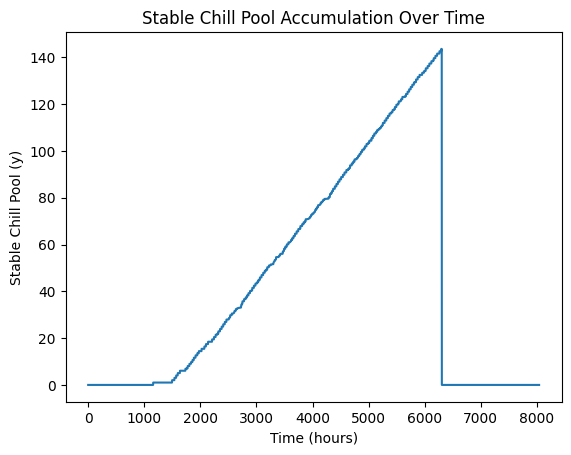

In [22]:
plt.plot(test['y'])
plt.xlabel('Time (hours)')
plt.ylabel('Stable Chill Pool (y)')
plt.title('Stable Chill Pool Accumulation Over Time')
plt.show()

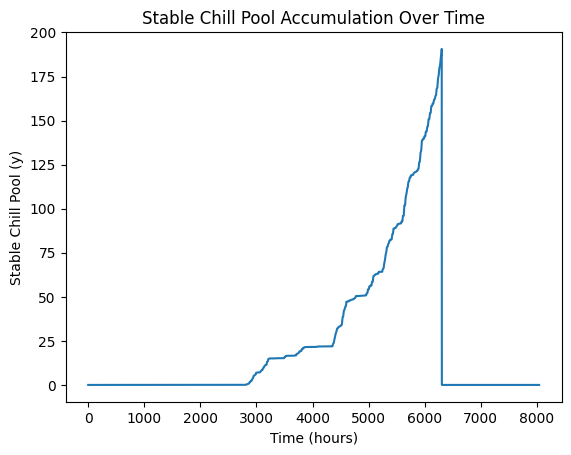

In [23]:
plt.plot(test['z'])
plt.xlabel('Time (hours)')
plt.ylabel('Stable Chill Pool (y)')
plt.title('Stable Chill Pool Accumulation Over Time')
plt.show()

In [24]:
test['bloomindex']

6304

Output the same as in R :)

In [25]:
phenoflex(temp = example_season[0].Temp, times=times_vector,
                 basic_output=True)

/tmp/ipykernel_347/182225480.py:20: RuntimeWarning: divide by zero encountered in scalar divide
  x = slope * Tf * (T - Tf) / T


{'bloomindex': 6304}

PhenoFlex for Numpyro

The cases in PhenoFlex where coded with jnp.where (e.g. when we check for temperature thresholds or when we check for the 1.0 threshold for conversion)

In addition a smooth bloom date is returned with a function expressing the difference to heat requirement. When accumulated heat is too low or exceed the threshold too much, then it is penalized. I need to penalize too high heat aswell, otherwise the function is waiting until the difference is maximized


In [74]:
# ── JAX helpers (vectorised, no Python loops) ─────────────────────────────────

def _p1z_jax(T, Tu, Tb, Tc):
    in_lower = (T >= Tb) & (T <= Tu)
    in_upper = (T > Tu) & (T <= Tc)
    val_lower = 0.5 * (1 + jnp.cos(jnp.pi + jnp.pi * (T - Tb) / (Tu - Tb)))
    val_upper = 1 + jnp.cos(jnp.pi / 2 + jnp.pi / 2 * (T - Tu) / (Tc - Tu))
    return jnp.where(in_lower, val_lower, jnp.where(in_upper, val_upper, 0.0))

def _p2z_jax(T, Tu, Delta):
    return jnp.exp(-((T - Tu) / (2 * Delta)) ** 2)

def _pfcn_jax(T, Tf, slope):
    x = slope * Tf * (T - Tf) / T
    sr = jnp.exp(jnp.clip(x, -20, 17))
    return jnp.where(x >= 17, 1.0, jnp.where(x <= -20, 0.0, sr / (1 + sr)))

# ── Soft bloom-date estimator ─────────────────────────────────────────────────

def soft_bloom_hour(z_trace, hours, zc, sharpness=1.0):
    """
    Differentiable approximation of the hour at which z first crosses zc.

    A hard argmax is not differentiable, so we use a softmax over (z - zc).
    As sharpness -> inf this converges to the true crossing point.
    Values of 0.5–2.0 work well in practice.

    Parameters
    ----------
    z_trace   : jnp array (N-1,) — accumulated heat at each time step
    hours     : jnp array (N-1,) — hours[i] is the time at which z_trace[i] was computed
    zc        : heat requirement threshold (scalar, can be a sampled parameter)
    sharpness : controls how peaked the soft-argmax is

    Returns
    -------
    Scalar: differentiable estimate of the bloom hour
    """
    #logits  = sharpness * (z_trace - zc)
    #this favpours to wait forever, until the difference is maxed.
    #this is ALWAYS at the end of the time series

    # MODIFIED: Use negative squared difference for logits
    logits  = -sharpness * (z_trace - zc)**2

    #new approach: negative bi
    # Numerically stable softmax
    logits  = logits - jnp.max(logits)
    weights = jnp.exp(logits)
    weights = weights / jnp.sum(weights)
    return jnp.dot(weights, hours)

# ── Numpyro model ─────────────────────────────────────────────────────────────

def phenoflex_numpyro(
    temp,
    times,
    bloom_doy_obs=None,
    start_doy=0.0,
    Imodel=0,
    deg_celsius=True,
    sharpness=1.0,
    return_traces=False, # New flag for conditional return
):
    """
    Numpyro probabilistic wrapper around PhenoFlex.

    The ONLY observable is the bloom date (day of year). z and y are latent
    state variables that are never observed directly.

    The forward pass accumulates heat (z) over the season. The predicted bloom
    date is the hour at which z crosses zc, converted to day-of-year via
    start_doy. Because argmax is not differentiable we use soft_bloom_hour()
    as a smooth approximation.

    Parameters
    ----------
    temp          : jnp array of hourly temperatures, length N
    times         : jnp array of hours since season start, length N
                    e.g. [0, 1, 2, ..., N-1] for consecutive hourly records
    bloom_doy_obs : observed bloom date as day-of-year (scalar or 1-D array
                    if multiple years are handled outside this function).
                    Pass None for prior predictive / generative mode.
    start_doy     : day-of-year corresponding to times[0].
                    E.g. if the season starts on Nov 1 = DOY 305, pass 305.
    Imodel        : 0 = GDH triangular bell, 1 = Gaussian
    deg_celsius   : True if temperatures arrive in Celsius
    sharpness     : steepness of the soft bloom-date estimator.
                    Increase if the posterior is diffuse; decrease if gradients vanish.
    return_traces : If True, x_trace, y_trace, and z_trace will be returned as deterministic outputs.
    """

    # ── Priors ────────────────────────────────────────────────────────────────
    yc    = numpyro.sample("yc",    dist.Normal(40.0,  10.0))
    zc    = numpyro.sample("zc",    dist.Normal(190.0, 30.0))
    s1    = numpyro.sample("s1",    dist.Beta(2.0, 2.0))
    E0    = numpyro.sample("E0",    dist.Normal(4153.5, 200.0))
    E1    = numpyro.sample("E1",    dist.Normal(12888.8, 500.0))
    A0    = numpyro.sample("A0",    dist.HalfNormal(139500))
    A1    = numpyro.sample("A1",    dist.HalfNormal(2567000000000000000))
    Tf    = numpyro.sample("Tf",    dist.Normal(4.0,   1.0))
    slope = numpyro.sample("slope", dist.HalfNormal(1.6))
    Tb    = numpyro.sample("Tb",    dist.Normal(4.0,   2.0))
    Tu    = numpyro.sample("Tu",    dist.Normal(26.0,  3.0))
    Tc    = numpyro.sample("Tc",    dist.Normal(36.0,  3.0))
    Delta = numpyro.sample("Delta", dist.HalfNormal(5.0))

    # Convert threshold temperatures to Kelvin
    offset = 273.0 if deg_celsius else 0.0
    _Tf = Tf + offset
    _Tu = Tu + offset
    _Tc = Tc + offset
    _Tb = Tb + offset

    # ── Forward pass via scan ─────────────────────────────────────────────────
    dt = times[1:] - times[:-1]   # shape (N-1,)

    def transition(carry, inputs):
        x_prev, y_prev, z_prev = carry
        ti_raw, dt_i = inputs

        ti = ti_raw + offset

        xs_i = A0 / A1 * jnp.exp(-(E0 - E1) / ti)
        k1   = A1 * jnp.exp(-E1 / ti)

        x_new = xs_i - (xs_i - x_prev) * jnp.exp(-k1 * dt_i)
        y_new = y_prev

        heat_rate = _p1z_jax(ti, _Tu, _Tb, _Tc) if Imodel == 0 else _p2z_jax(ti, _Tu, Delta)
        z_new = z_prev + heat_rate * _pfcn_jax(y_prev, yc, s1) * dt_i

        # Labile -> stable chill conversion
        delta   = _pfcn_jax(ti, _Tf, slope) * x_new
        convert = jnp.where(x_new >= 1.0, 1.0, 0.0)
        y_new   = y_new + convert * delta
        x_new   = x_new - convert * delta

        return (x_new, y_new, z_new), (x_new, y_new, z_new) # Return all states to be traced

    init   = (jnp.array(0.0), jnp.array(0.0), jnp.array(0.0))
    inputs = (temp[:-1], dt)

    (_, _, _), (x_trace, y_trace, z_trace) = scan(transition, init, inputs)
    # x_trace[i], y_trace[i], z_trace[i] = states after processing hour i+1

    if return_traces:
        numpyro.deterministic("x_trace", x_trace)
        numpyro.deterministic("y_trace", y_trace)
        numpyro.deterministic("z_trace", z_trace)

    # ── Predicted bloom date ──────────────────────────────────────────────────
    # times[1:] are the hours at which each z value was recorded
    bloom_hour     = soft_bloom_hour(z_trace, times[1:], zc, sharpness=sharpness)
    bloom_doy_pred = numpyro.deterministic(
        "bloom_doy_pred",
        start_doy + bloom_hour / 24.0 - 0.5, # Subtract 0.5 days (12 hours) to center at midday
    )

    # ── Observation noise ─────────────────────────────────────────────────────
    # Bloom phenology observations carry real uncertainty from observer error,
    # the definition of first-flower, spatial variability, etc.
    # A few days of SD is typical for field phenology data.
    sigma = numpyro.sample("sigma", dist.HalfNormal(3.0))  # days

    # ── Likelihood ────────────────────────────────────────────────────────────
    if bloom_doy_obs is not None:
        # Inference mode: condition on observed bloom date
        numpyro.sample("bloom_doy", dist.Normal(bloom_doy_pred, sigma),
                       obs=bloom_doy_obs)


For experimenting with the function, I fixed the model parameters


In [75]:
from numpyro.infer import Predictive

# Define some example fixed parameters. sigma must be > 0.
fixed_params = {
    "yc": 40.0,
    "zc": 190.0,
    "s1": 0.5,
    "E0": 4153.5,
    "E1": 12888.8,
    "A0": 139500.0,
    "A1": 2.567e+18, # Use scientific notation for large numbers
    "Tf": 4.0,
    "slope": 1.6,
    "Tb": 4.0,
    "Tu": 26.0,
    "Tc": 36.0,
    "Delta": 4.0
}

# Condition the model with the fixed parameters
conditioned_model = numpyro.handlers.condition(phenoflex_numpyro,
                                               data=fixed_params)

# Prepare data for the phenoflex_numpyro model
season_temp = jnp.asarray(example_season[0].Temp.values) # Convert pandas Series to JAX array
season_times = jnp.asarray(times_vector) # Use the previously created times_vector
start_doy = example_season[0].iloc[0]['JDay'] - (example_season[0].iloc[0]['Hour'] / 24.0) if 'Hour' in example_season[0].columns else example_season[0].iloc[0]['JDay']


Run the model with example temperature time series. the argument return_traces allows to return the modeled subprocesses. The function returns the bloomdate.

In [76]:
# Run a predictive simulation with the fixed parameters
# We don't provide bloom_doy_obs here to get the predicted bloom_doy_pred
predictive = Predictive(conditioned_model, num_samples=1) # num_samples=1 as parameters are fixed
rng_key, _ = random.split(random.PRNGKey(0))
predictions = predictive(rng_key,
                         temp=season_temp,
                         times=season_times,
                         start_doy=start_doy,
                         sharpness = 1,
                         Imodel=0,
                         return_traces=True) # Request to return traces

#if doy > 365, subtract 365
predictions['bloom_doy_pred'] = jnp.where(predictions['bloom_doy_pred'] > 365, predictions['bloom_doy_pred'] - 365, predictions['bloom_doy_pred'])

print("Predicted bloom day of year with fixed parameters:", predictions['bloom_doy_pred'].item())

Predicted bloom day of year with fixed parameters: 110.08349609375


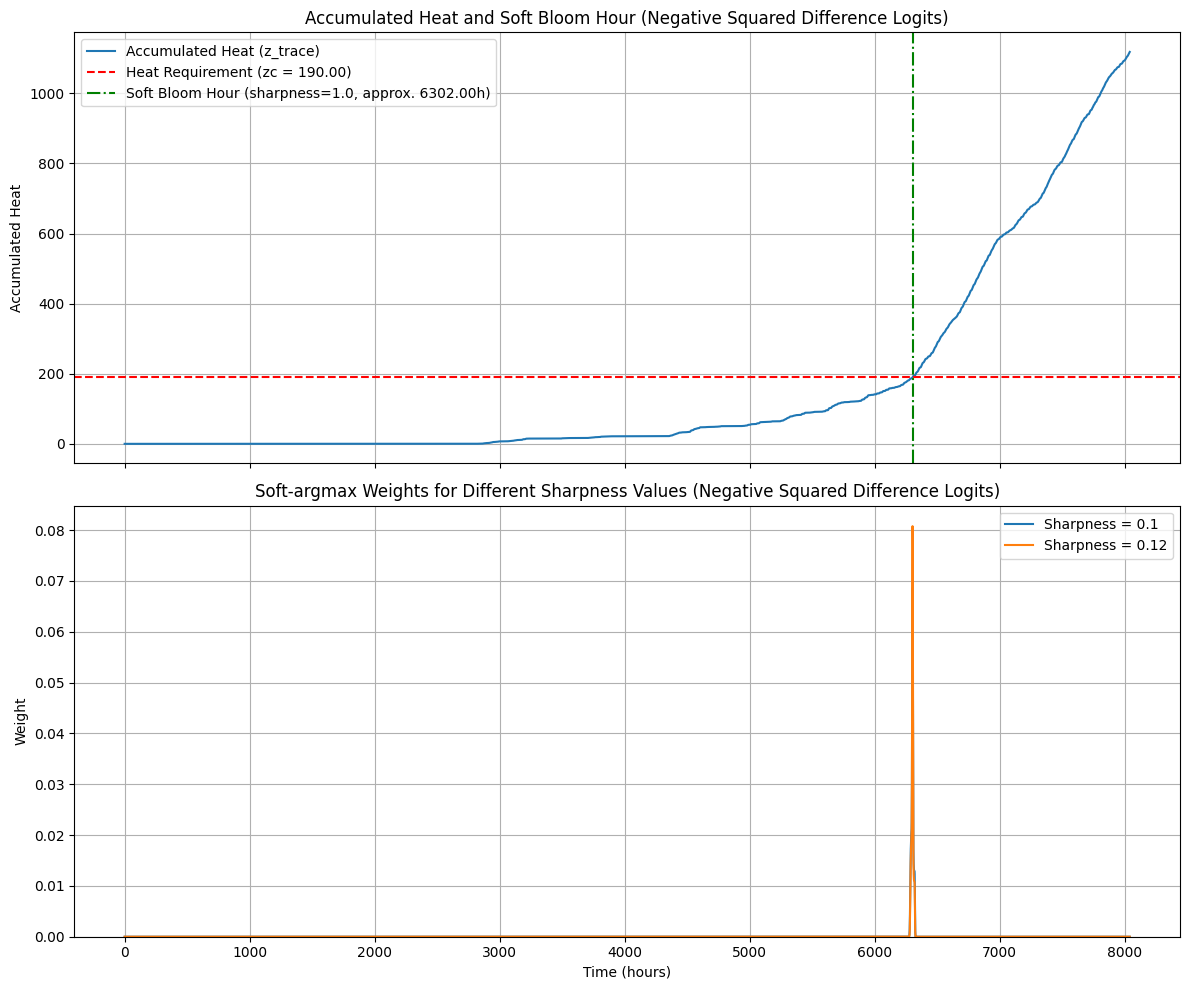

In [66]:
import matplotlib.pyplot as plt
import jax.numpy as jnp

# Extract relevant data for plotting
z_trace = predictions['z_trace'][0] # Take the first sample from predictions
zc = predictions['zc'][0]
hours = season_times[1:] # Hours corresponding to z_trace
bloom_doy_pred = predictions['bloom_doy_pred'].item()

# Calculate bloom hour from predicted bloom doy (since start_doy was used in model)
# start_doy = example_season[0].iloc[0]['JDay'] - (example_season[0].iloc[0]['Hour'] / 24.0) if 'Hour' in example_season[0].columns else example_season[0].iloc[0]['JDay']
# This is more direct, as predictions['bloom_doy_pred'] already accounts for start_doy
# So bloom_hour = (bloom_doy_pred - start_doy) * 24.0

# The soft_bloom_hour function returns the hour directly, so we use that.
# Let's re-calculate it for default sharpness for marking.
def get_soft_bloom_hour_and_weights(z_trace, hours, zc, sharpness):
    # MODIFIED: Use negative squared difference for logits
    logits  = -sharpness * (z_trace - zc)**2
    # Numerically stable softmax
    logits  = logits - jnp.max(logits)
    weights = jnp.exp(logits)
    weights = weights / jnp.sum(weights)
    bloom_hour_val = jnp.dot(weights, hours)
    return bloom_hour_val, weights

bloom_hour_default, _ = get_soft_bloom_hour_and_weights(z_trace, hours, zc, sharpness=1.0) # Using sharpness=1.0 as the default in the model if not specified

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Subplot 1: Z-trace and Zc threshold
ax1.plot(hours, z_trace, label='Accumulated Heat (z_trace)')
ax1.axhline(zc, color='r', linestyle='--', label=f'Heat Requirement (zc = {zc:.2f})')
ax1.axvline(bloom_hour_default, color='g', linestyle='-.', label=f'Soft Bloom Hour (sharpness=1.0, approx. {bloom_hour_default:.2f}h)')
ax1.set_ylabel('Accumulated Heat')
ax1.set_title('Accumulated Heat and Soft Bloom Hour (Negative Squared Difference Logits)')
ax1.legend()
ax1.grid(True)

# Subplot 2: Weights for different sharpness values
sharpness_values = [0.1, 0.12]
for s in sharpness_values:
    _, weights = get_soft_bloom_hour_and_weights(z_trace, hours, zc, sharpness=s)
    ax2.plot(hours, weights, label=f'Sharpness = {s}')

ax2.set_xlabel('Time (hours)')
ax2.set_ylabel('Weight')
ax2.set_title('Soft-argmax Weights for Different Sharpness Values (Negative Squared Difference Logits)')
ax2.legend()
ax2.grid(True)
ax2.set_ylim(bottom=0) # Ensure weights start from 0

plt.tight_layout()
plt.show()

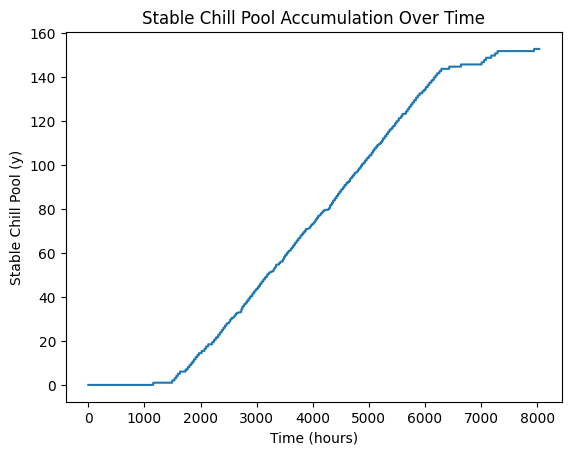

In [41]:
plt.plot(predictions['y_trace'][0])
plt.xlabel('Time (hours)')
plt.ylabel('Stable Chill Pool (y)')
plt.title('Stable Chill Pool Accumulation Over Time')
plt.show()

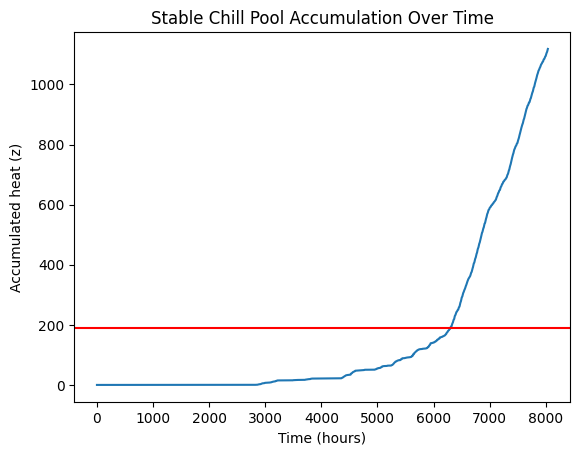

In [45]:
plt.plot(predictions['z_trace'][0])
plt.axhline(predictions['zc'][0], color = 'r')
plt.xlabel('Time (hours)')
plt.ylabel('Accumulated heat (z)')
plt.title('Stable Chill Pool Accumulation Over Time')
plt.show()

In [79]:
# Define some example fixed parameters. sigma must be > 0.
fixed_params = {
    "E0": 4153.5,
    "E1": 12888.8,
    "A0": 139500.0,
    "A1": 2.567e+18, # Use scientific notation for large numbers
    "Tf": 4.0,
    "slope": 1.6,
    "Tb": 4.0,
    "Tu": 26.0,
    "Tc": 36.0,
    "Delta": 4.0
}

# Condition the model with the fixed parameters
conditioned_model = numpyro.handlers.condition(phenoflex_numpyro,
                                               data=fixed_params)

# Prepare data for the phenoflex_numpyro model
season_temp = jnp.asarray(example_season[0].Temp.values) # Convert pandas Series to JAX array
season_times = jnp.asarray(times_vector) # Use the previously created times_vector
start_doy = example_season[0].iloc[0]['JDay'] - (example_season[0].iloc[0]['Hour'] / 24.0) if 'Hour' in example_season[0].columns else example_season[0].iloc[0]['JDay']

# Run a predictive simulation with the fixed parameters
# We don't provide bloom_doy_obs here to get the predicted bloom_doy_pred
predictive = Predictive(conditioned_model, num_samples=10) # num_samples=1 as parameters are fixed
rng_key, _ = random.split(random.PRNGKey(0))
predictions = predictive(rng_key,
                         temp=season_temp,
                         times=season_times,
                         start_doy=start_doy,
                         sharpness = 1,
                         Imodel=0,
                         return_traces=True) # Request to return traces

#if doy > 365, subtract 365
predictions['bloom_doy_pred'] = jnp.where(predictions['bloom_doy_pred'] > 365, predictions['bloom_doy_pred'] - 365, predictions['bloom_doy_pred'])


In [80]:
predictions['bloom_doy_pred']

Array([ 84.27637, 111.18829, 103.57962, 111.22821, 113.00372, 110.09247,
       107.38043, 111.17905, 109.30948,  82.20352], dtype=float32)

In [ ]:
def crop_model(init=None,n_timesteps=100,L_t=None, w_t=None):
    # Define prior distributions
    Is = numpyro.sample("Is", dist.Exponential(1))*10
    epsilon = numpyro.sample("epsilon", dist.Exponential(1))/1000 # (kg/MJ)
    k = numpyro.sample("k", dist.Exponential(2))
    p = numpyro.sample("p", dist.Exponential(2))
    s = numpyro.sample("s", dist.Exponential(1))*10 # m2/kg

    def transition(carry, _):
        # get values from previous period
        L_prev, w_prev = carry

        # Calcualte Intercepted PAR (MJ m-2 d-1)
        Ipar = Is*(1-jnp.exp(-k*L_prev))
        # Calcualte change in biomass
        dw = Ipar*epsilon
        # Calculate change in Leafareaindex
        dL = s*p*dw
        # Update Leafareaindex and biomass
        L_t = numpyro.sample("L_t", dist.Normal(L_prev+dL, .1))
        # L_t = numpyro.deterministic("L_t", L_prev+dL) # determinstic model
        # L_t = L_prev+dL # determinstic model

        # Update biomass (kg/sqm)
        w_t = numpyro.sample('w_t',dist.Normal(w_prev+dw,.1))
        # w_t = numpyro.deterministic('w_t',w_prev+dw) #determinstic model

        # Update what is carried to the next iternation
        carry = (L_t, w_t)
        return carry, None

    # Inference mode
    if L_t is not None:
        timesteps = jnp.arange(L_t.shape[0] - 1)
        init = (L_t[0], w_t[0])
        with numpyro.handlers.condition(data={"L_t": L_t[1:], "w_t":w_t[1:]}):
            scan(transition, init, timesteps)
    # Generative mode
    else:
        timesteps = jnp.arange(n_timesteps)
        scan(transition, init, timesteps)



In [ ]:
# Run the model forward (i.e. generate artifical data)
num_data = 50 # number of time period
rng_key = jax.random.PRNGKey(1) # random seed
t = jnp.arange(0, num_data) # array for t

# Set parameters, same as in lecture slides from Thomas Gaiser
coefTrue = {
          'Is':1.8, # (scaled in model by *10, was 18 MJ m-2 d-1 in slides)
          'epsilon':3,
          'k':0.7,
          'p':0.5,
          's':2, # (in model scaled to m2/kg, was 0.02 m2/g in slides)
          }
condition_model = numpyro.handlers.condition(crop_model, data=coefTrue)
prior_predictive = Predictive(condition_model, num_samples=1)

# set start values (same as used in lecture slides)
L_zero = 0.2
w_zero = 0.1/1000 # (kg/sqm)

# Sample Y from model
rng_key, rng_key_ = random.split(rng_key)
prior_samples = prior_predictive(rng_key_,init=(L_zero, w_zero), n_timesteps=num_data)

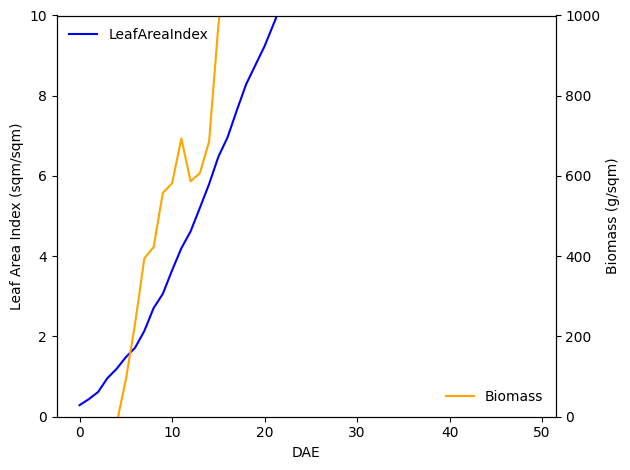

In [ ]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(t, prior_samples['L_t'][0,:], label='LeafAreaIndex',color='blue');
ax2.plot(t, prior_samples['w_t'][0,:]*1000, label='Biomass',color='orange');
ax1.legend(loc='upper left', frameon=False)
ax2.legend(loc='lower right', frameon=False)

ax1.set_ylabel('Leaf Area Index (sqm/sqm)')
ax2.set_ylabel('Biomass (g/sqm)')
ax1.set_xlabel('DAE')


ax1.set_ylim(0,10)
ax2.set_ylim(0,1000)
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

In [ ]:
# Get "observations" from one draw of the prior
L_t = prior_samples['L_t'][0]
w_t = prior_samples['w_t'][0]

true_Is = prior_samples['Is'][0]
true_epsilon = prior_samples['epsilon'][0]
true_k = prior_samples['k'][0]
true_p = prior_samples['p'][0]
true_s = prior_samples['s'][0]

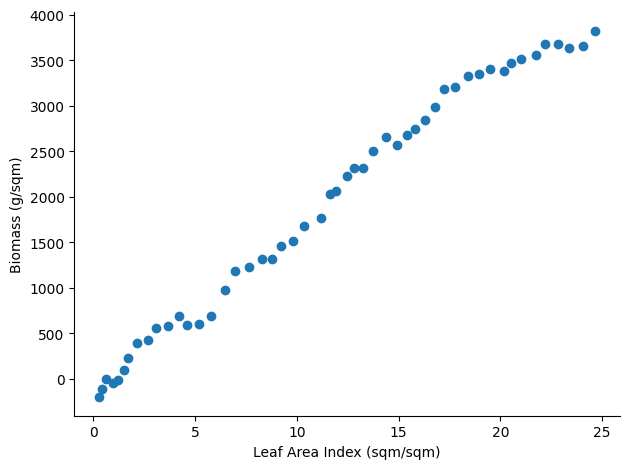

In [ ]:
fig, ax = plt.subplots()
ax.scatter(L_t,w_t*1000)

ax.set_xlabel('Leaf Area Index (sqm/sqm)')
ax.set_ylabel('Biomass (g/sqm)')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()




In [ ]:
# Estimate the model using PP, taking the "observed" data
# (i.e. the one generated before)
dat = {'L_t':L_t,
       'w_t':w_t,
      'init':None}

args = {}
args['num_warmup'] = 1000
args['num_samples'] = 1000
args['num_chains'] = 2
model = crop_model

mcmc, mcmc_samples, az_mcmc = run_inference(crop_model, args, rng_key, dat)

/tmp/ipykernel_603/719121536.py:4: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = numpyro.infer.MCMC(
sample: 100%|██████████| 2000/2000 [00:03<00:00, 506.83it/s, 127 steps of size 2.64e-02. acc. prob=0.95]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
        Is      3.03      1.30      2.77      1.13      4.94    853.17      1.00
   epsilon      3.06      1.32      2.80      1.17      4.97    778.55      1.00
         k      0.85      0.17      0.83      0.58      1.12    916.04      1.00
         p      0.70      0.45      0.59      0.14      1.33    674.66      1.00
         s      1.45      0.96      1.18      0.28      2.79    591.87      1.00

Number of divergences: 0

MCMC elapsed time: 21.62435293197632


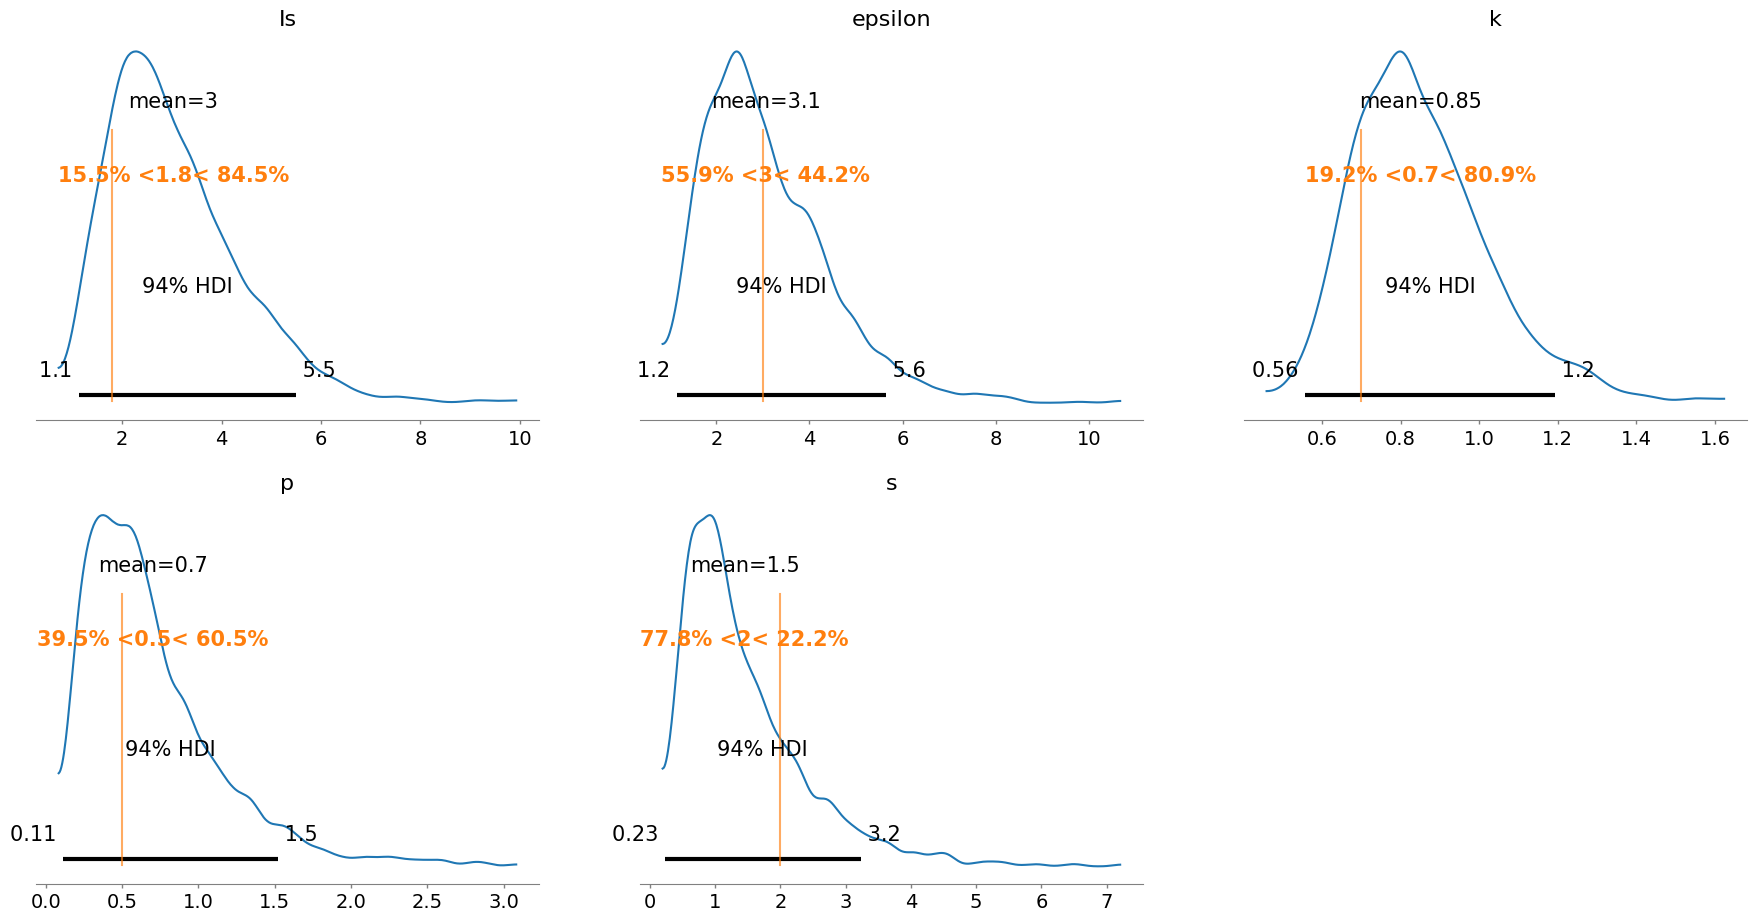

In [ ]:
# Plot posterior estimates
az.plot_posterior(az_mcmc,
            ref_val=[
                true_Is,
                true_epsilon,
                true_k,
                true_p,
                true_s
            ]);